# İkinci El Araç Fiyat Tahmini — Model Eğitimi

arabam.com'dan derlenmiş ~50 bin ilanla (Ağustos 2025) bir aracın fiyatını tahmin eden model kuruyoruz.

**Plan:** veriyi incele → temizle → basit modelle başla (doğrusal regresyon) → güçlü modellerle karşılaştır
(random forest, gradient boosting) → hatayı TL cinsinden yorumla → en iyi modeli kaydet → Streamlit arayüzü (`app.py`).

## 1. Kütüphaneler ve veri

In [1]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

CIKTI, MODEL = Path("cikti"), Path("model")
CIKTI.mkdir(exist_ok=True); MODEL.mkdir(exist_ok=True)

# Grafik stili
METIN, IKINCIL, SOLUK, IZGARA, KENAR, ANA = "#0b0b0b", "#52514e", "#8a8984", "#e6e5e0", "#c3c2b7", "#2a78d6"
def sayi(v, o=0):
    return f"{v:,.{o}f}".replace(",", "X").replace(".", ",").replace("X", ".")
def sade(ax):
    ax.grid(axis="y", color=IZGARA, linewidth=0.8)
    for k in ("top", "right"): ax.spines[k].set_visible(False)
    for k in ("left", "bottom"): ax.spines[k].set_color(KENAR)
    ax.tick_params(colors=IKINCIL)

ham = pd.read_csv("data/car_price_prediction.csv")
print(ham.shape)
ham.head()

(50755, 16)


,id,marka,seri,model,yil,kilometre,vites_tipi,yakit_tipi,kasa_tipi,renk,motor_hacmi,motor_gucu,degisen_sayisi,boyali_sayisi,kimden,fiyat
0,1,Lexus,ES,300h Business Plus,2023.0,43000.0,Otomatik,Benzin,Sedan,Siyah,2250.0,213.0,1.0,1.0,Galeriden,4950000.0
1,2,Lexus,GS,200t Luxury,2023.0,25000.0,Otomatik,Benzin,Hatchback/5,Mavi,NaN,213.0,1.0,0.0,Galeriden,1265000.0
2,3,Lexus,LS,500h Exclusive,2021.0,23665.0,Otomatik,Benzin,Sedan,Siyah,3250.0,363.0,0.0,0.0,Galeriden,9000000.0
3,4,Kuba,City,NaN,2024.0,0.0,Otomatik,Elektrik,Hatchback/3,Kahverengi,NaN,50.0,0.0,0.0,Galeriden,279999.0
4,5,Lexus,GS,200t F Sport,2016.0,90500.0,Otomatik,Benzin,Sedan,Beyaz,1900.0,238.0,0.0,0.0,Galeriden,2745000.0


## 2. Veriyi inceleme

### Eksik değerler

In [2]:
eksik = ham.isna().sum()
eksik[eksik > 0].sort_values(ascending=False).to_frame("eksik_satir")

,eksik_satir
boyali_sayisi,10416
degisen_sayisi,10416
motor_gucu,1661
motor_hacmi,1627
model,331
vites_tipi,183
kasa_tipi,175
renk,159
yakit_tipi,158
yil,158


- 158 satırda fiyat dahil neredeyse her şey boş — bunlar kullanılamaz, atılacak.
- `degisen_sayisi` / `boyali_sayisi` ilanların ~%20'sinde yok: satıcı bu bilgiyi girmemiş. Atmak yerine
  "bilgi yok" olarak işaretleyip dolduracağız (bilginin **olmaması** da fiyat hakkında bir şey söyleyebilir).
- Motor hacmi / gücü az sayıda satırda eksik; medyanla doldurulacak.

### Aykırı değerler

In [3]:
ham[["fiyat", "kilometre", "yil", "motor_gucu"]].describe(percentiles=[.005, .5, .995]).round(0)

,fiyat,kilometre,yil,motor_gucu
count,50597.0,50597.0,50597.0,49094.0
mean,925597.0,198079.0,2010.0,115.0
std,4454394.0,624124.0,9.0,54.0
min,10000.0,0.0,1951.0,39.0
0.5%,99994.0,6002.0,1988.0,57.0
50%,608000.0,189000.0,2012.0,105.0
99.5%,6990180.0,519020.0,2024.0,513.0
max,595000000.0,90000000.0,2025.0,1000.0


90 milyon km'lik araba ya da 595 milyon TL'lik ilan gerçek değil (yazım hatası ya da süper lüks tek tük araçlar).
Bunlar modeli bozar. Kurallar:
- Fiyat: en alttaki ve en üstteki %0,5'lik dilim atılır → model **~100 bin – 7 milyon TL** aralığı için geçerli
- Kilometre ≤ 1.000.000, model yılı ≥ 1980, motor gücü ≤ 600 hp

### Veri hakkında bir not

In [4]:
ham["marka"].value_counts().head(10)

marka
BMW                2491
Tofaş              2491
Toyota             2490
Citroen            2489
Fiat               2487
Peugeot            2487
Hyundai            2486
Volkswagen         2486
Mercedes - Benz    2485
Audi               2483
Name: count, dtype: int64

İlk ~30 markanın her birinden **neredeyse tam 2.490 ilan** var: veri seti marka başına eşit örneklenmiş. Yani piyasadaki
gerçek dağılımı (Türkiye'de çok daha fazla Renault/Fiat satılır) yansıtmıyor. Bu model için sorun değil — her markayı
eşit iyi öğrenmesi iyi bir şey — ama "en çok satılan marka" gibi analizler bu veriyle yapılmamalı.

## 3. Temizlik

In [5]:
alt, ust = ham["fiyat"].quantile([0.005, 0.995])
df = ham.dropna(subset=["fiyat"])
df = df[
    df["fiyat"].between(alt, ust)
    & (df["kilometre"] <= 1_000_000)
    & (df["yil"] >= 1980)
    & ~(df["motor_gucu"] > 600)  # eksik olanlar kalsın, sonra doldurulacak
].copy()
df["kimden"] = df["kimden"].replace({"Rent a Car": "Galeriden"})  # sadece 4 ilan

print(f"{len(ham):,} → {len(df):,} satır  |  fiyat aralığı: {sayi(alt)} – {sayi(ust)} TL".replace(",", "."))

50.755 → 50.000 satır  |  fiyat aralığı: 99.994 – 6.990.180 TL


### Temel grafikler

Fiyat dağılımı çok sağa çarpık: çoğu ilan 300 bin – 1 milyon TL arasında, az sayıda çok pahalı araç var.
Logaritmik ölçekte dağılım neredeyse simetrik hale geliyor — bu yüzden model **fiyatın logaritmasını** tahmin edecek.
Bunun pratik anlamı: 300 bin TL'lik arabada 50 bin TL hata büyük, 5 milyonluk arabada küçük; log ölçeği modeli
hatayı **oransal** düşünmeye zorluyor.

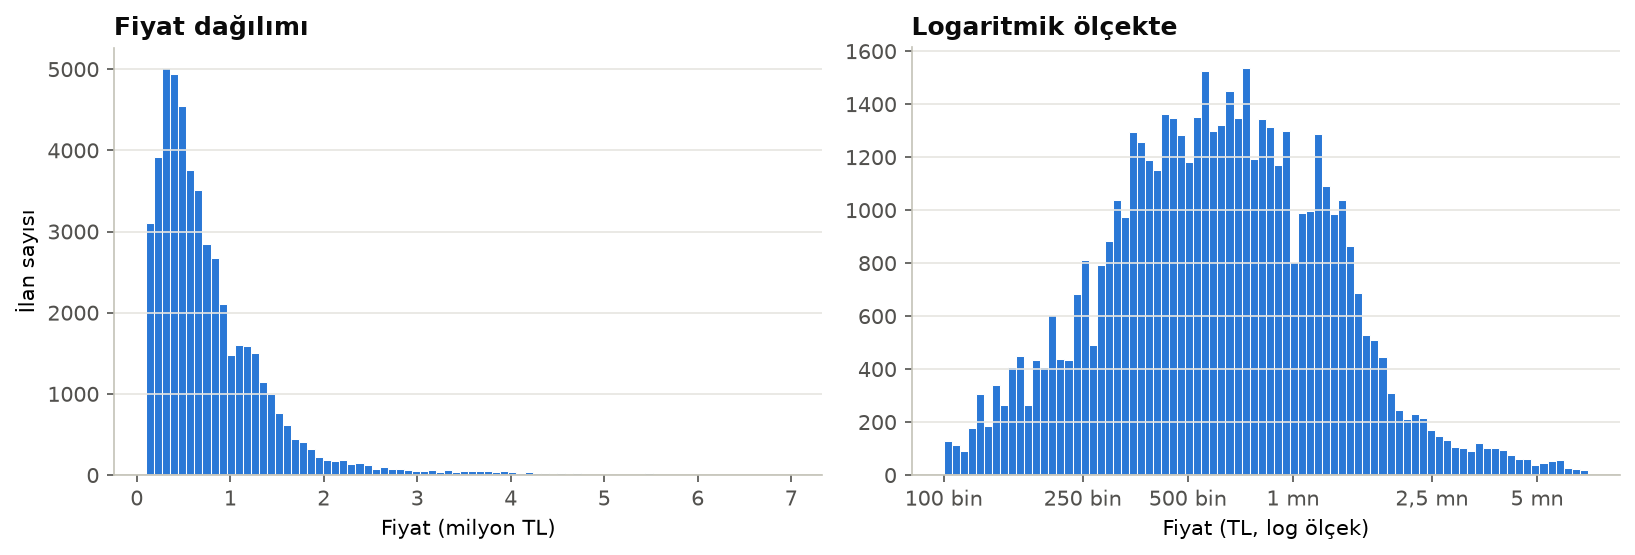

In [6]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.8), dpi=150)
a1.hist(df["fiyat"] / 1e6, bins=80, color=ANA, edgecolor="white", linewidth=0.5)
a1.set_title("Fiyat dağılımı", loc="left", fontweight="bold", color=METIN)
a1.set_xlabel("Fiyat (milyon TL)"); a1.set_ylabel("İlan sayısı")
a2.hist(np.log10(df["fiyat"]), bins=80, color=ANA, edgecolor="white", linewidth=0.5)
a2.set_title("Logaritmik ölçekte", loc="left", fontweight="bold", color=METIN)
isaretler = [1e5, 2.5e5, 5e5, 1e6, 2.5e6, 5e6]
a2.set_xticks(np.log10(isaretler), ["100 bin", "250 bin", "500 bin", "1 mn", "2,5 mn", "5 mn"])
a2.set_xlabel("Fiyat (TL, log ölçek)")
for a in (a1, a2): sade(a)
fig.tight_layout(); fig.savefig(CIKTI / "fiyat_dagilimi.png", bbox_inches="tight"); plt.show()

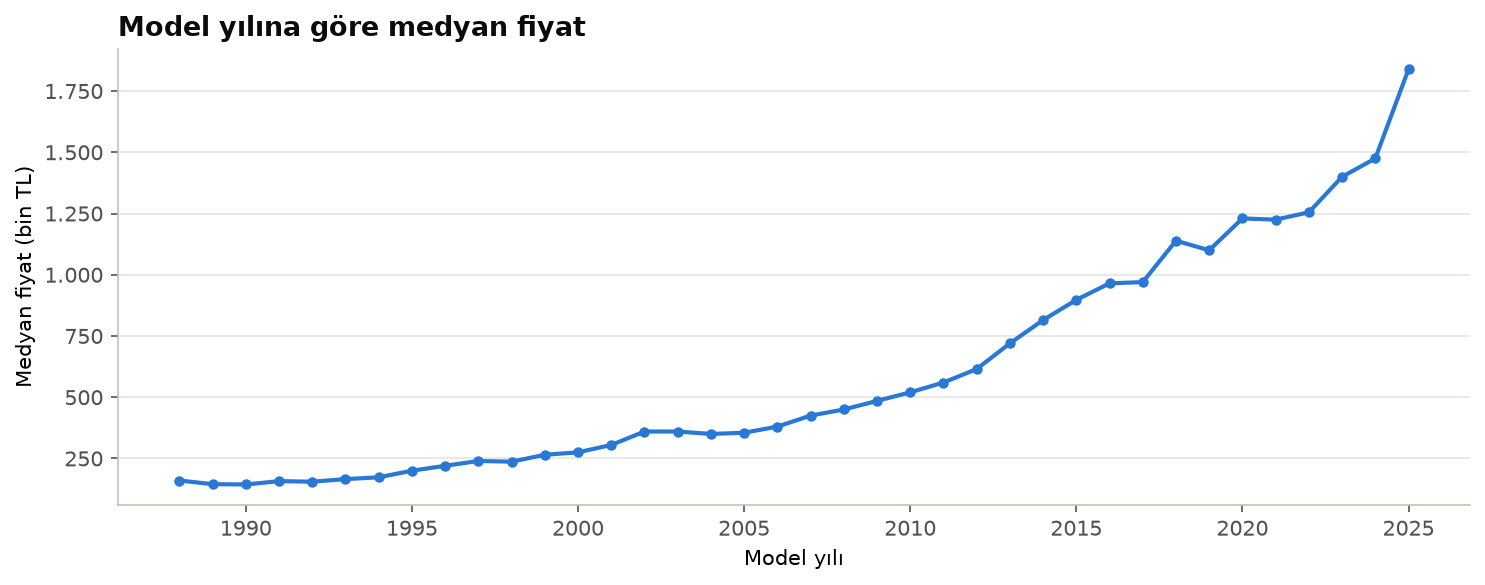

In [7]:
yas = df.groupby("yil")["fiyat"].median()
yas = yas[df["yil"].value_counts().sort_index() >= 50]  # az ilanlı yılları gösterme

fig, ax = plt.subplots(figsize=(10, 4), dpi=150)
ax.plot(yas.index, yas.values / 1e3, color=ANA, linewidth=2, marker="o", markersize=4)
ax.set_title("Model yılına göre medyan fiyat", loc="left", fontsize=13, fontweight="bold", color=METIN)
ax.set_xlabel("Model yılı"); ax.set_ylabel("Medyan fiyat (bin TL)")
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: sayi(v)))
sade(ax); fig.tight_layout(); fig.savefig(CIKTI / "yil_fiyat.png", bbox_inches="tight"); plt.show()

## 4. Modele hazırlık

**Kullanılan sütunlar:** marka, seri, vites, yakıt, kasa tipi, renk, satıcı tipi (kategorik) ve yıl, kilometre,
motor hacmi, motor gücü, değişen / boyalı parça sayısı (sayısal).

`model` sütunu (3.302 farklı değer — "1.6 TDI Style" gibi donanım paketleri) **kullanılmadı**: arayüzde kullanıcıya
binlerce seçenek sunmak pratik değil, donanım farkının önemli kısmını da motor hacmi/gücü zaten taşıyor.

**Kategorik → sayı:**
- Doğrusal regresyon için *one-hot*: her kategori ayrı bir 0/1 sütunu olur.
- Ağaç modelleri için *ordinal*: her kategoriye bir tam sayı verilir (ağaçlar sıralamaya takılmaz).
- 30'dan az ilanı olan seriler "nadir" diye tek grupta toplanır; modelin 3-5 ilanlık serileri ezberlemesini önler.

**Eğitim / test:** verinin %80'iyle eğitip, modelin hiç görmediği %20 üzerinde ölçüyoruz.

In [8]:
KATEGORIK = ["marka", "seri", "vites_tipi", "yakit_tipi", "kasa_tipi", "renk", "kimden"]
SAYISAL = ["yil", "kilometre", "motor_hacmi", "motor_gucu", "degisen_sayisi", "boyali_sayisi"]

X, y = df[KATEGORIK + SAYISAL], df["fiyat"]
X_egitim, X_test, y_egitim, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Eğitim: {len(X_egitim):,}  |  Test: {len(X_test):,}".replace(",", "."))

def model_kur(regresor, one_hot):
    if one_hot:
        kodlayici = OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=30)
    else:
        kodlayici = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1,
                                   encoded_missing_value=-1, min_frequency=30)
    on_isleme = ColumnTransformer([
        ("kategorik", make_pipeline(SimpleImputer(strategy="most_frequent"), kodlayici), KATEGORIK),
        # add_indicator: eksik değer doldurulurken "bu bilgi yoktu" diye ayrı bir 0/1 sütunu da eklenir
        ("sayisal", SimpleImputer(strategy="median", add_indicator=True), SAYISAL),
    ])
    # Model log(fiyat) öğrenir; tahminler otomatik olarak TL'ye geri çevrilir.
    return TransformedTargetRegressor(make_pipeline(on_isleme, regresor), func=np.log, inverse_func=np.exp)

def olc(ad, model):
    tahmin = model.predict(X_test)
    yuzde_hata = np.abs(tahmin - y_test) / y_test
    return {"model": ad,
            "MAE (TL)": mean_absolute_error(y_test, tahmin),
            "medyan % hata": np.median(yuzde_hata) * 100,
            "R²": r2_score(y_test, tahmin)}

Eğitim: 40.000  |  Test: 10.000


## 5. Önce basit model: doğrusal regresyon

Her özelliğe bir ağırlık veren, fiyatı bunların toplamı olarak hesaplayan en basit model. Karşılaştırma için bir taban çizgisi.

In [9]:
dogrusal = model_kur(LinearRegression(), one_hot=True).fit(X_egitim, y_egitim)
sonuclar = [olc("Doğrusal regresyon", dogrusal)]
pd.DataFrame(sonuclar).round(3)

,model,MAE (TL),medyan % hata,R²
0,Doğrusal regresyon,176648.423,16.072,0.673


## 6. Random forest ile karşılaştırma

Yüzlerce karar ağacının ortalaması. "2015 üstü **ve** dizel **ve** 150 bin km altı" gibi özellikler arası etkileşimleri
kendisi yakalayabilir — doğrusal modelin yapamadığı şey.

In [10]:
orman = model_kur(RandomForestRegressor(n_estimators=200, min_samples_leaf=2, n_jobs=-1, random_state=42),
                  one_hot=False).fit(X_egitim, y_egitim)
sonuclar.append(olc("Random forest", orman))
joblib.dump(orman, MODEL / "gecici_orman.joblib", compress=3)
orman_mb = (MODEL / "gecici_orman.joblib").stat().st_size / 1e6
(MODEL / "gecici_orman.joblib").unlink()
print(f"Random forest dosya boyutu: {orman_mb:.0f} MB")
pd.DataFrame(sonuclar).round(3)

Random forest dosya boyutu: 95 MB


,model,MAE (TL),medyan % hata,R²
0,Doğrusal regresyon,176648.423,16.072,0.673
1,Random forest,76007.817,7.319,0.941


Random forest hatayı yarıdan fazla düşürüyor. Ama dosyası çok büyük: GitHub'ın dosya başına 100 MB sınırına dayanıyor
ve ücretsiz sunucuda arayüzün açılmasını yavaşlatır. Aynı başarıyı daha küçük bir modelle yakalayabilir miyiz?

### Gradient boosting

Ağaçları tek tek, her biri öncekinin hatasını düzeltecek şekilde kurar. Marka ve seriyi gerçek kategori olarak
işleyebiliyor (sayı gibi değil).

In [11]:
boosting = model_kur(HistGradientBoostingRegressor(max_iter=800, learning_rate=0.05,
                                                   categorical_features=list(range(len(KATEGORIK))),
                                                   random_state=42),
                     one_hot=False).fit(X_egitim, y_egitim)
sonuclar.append(olc("Gradient boosting", boosting))
joblib.dump(boosting, MODEL / "fiyat_modeli.joblib", compress=3)
boosting_mb = (MODEL / "fiyat_modeli.joblib").stat().st_size / 1e6

tablo = pd.DataFrame(sonuclar)
tablo["dosya (MB)"] = [0.0, orman_mb, boosting_mb]
tablo.round(3)

,model,MAE (TL),medyan % hata,R²,dosya (MB)
0,Doğrusal regresyon,176648.423,16.072,0.673,0.000
1,Random forest,76007.817,7.319,0.941,95.090
2,Gradient boosting,73199.511,7.174,0.944,0.468


## 7. Hatayı yorumlama

**MAE (ortalama mutlak hata):** tahminlerin gerçek fiyattan ortalama kaç TL saptığı.
**Medyan % hata:** tipik bir ilanda yüzde kaç yanıldığımız — fiyat aralığı çok geniş olduğu için daha adil bir ölçü.

Gradient boosting ortalama 73.200 TL yanılıyor; tipik bir ilanda hata %7,2.
Doğrusal regresyona göre hata %59 daha düşük; random forest ile aynı seviyede ama dosyası 203 kat küçük.


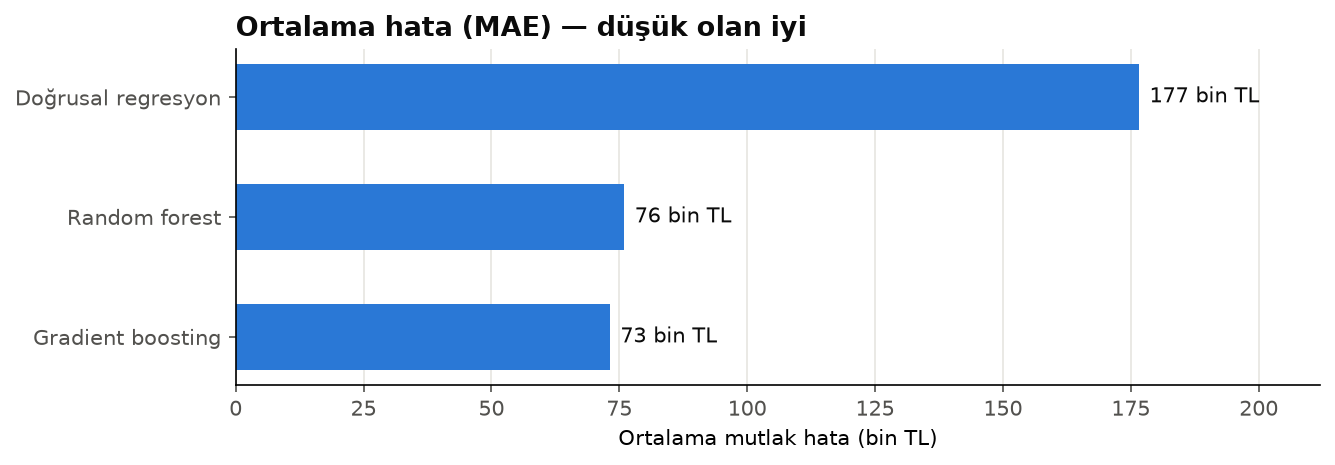

In [12]:
en_iyi = tablo.iloc[2]
print(f"Gradient boosting ortalama {sayi(en_iyi['MAE (TL)'])} TL yanılıyor; "
      f"tipik bir ilanda hata %{sayi(en_iyi['medyan % hata'], 1)}.")
print(f"Doğrusal regresyona göre hata %{sayi((1 - en_iyi['MAE (TL)'] / tablo.iloc[0]['MAE (TL)']) * 100, 0)} daha düşük; "
      f"random forest ile aynı seviyede ama dosyası {orman_mb / boosting_mb:.0f} kat küçük.")

fig, ax = plt.subplots(figsize=(9, 3.2), dpi=150)
ax.barh(tablo["model"][::-1], tablo["MAE (TL)"][::-1] / 1e3, color=ANA, height=0.55)
for i, v in enumerate(tablo["MAE (TL)"][::-1] / 1e3):
    ax.text(v + 2, i, f"{sayi(v)} bin TL", va="center", fontsize=10, color=METIN)
ax.set_title("Ortalama hata (MAE) — düşük olan iyi", loc="left", fontsize=13, fontweight="bold", color=METIN)
ax.set_xlabel("Ortalama mutlak hata (bin TL)")
ax.grid(axis="x", color=IZGARA, linewidth=0.8); ax.set_axisbelow(True)
for k in ("top", "right"): ax.spines[k].set_visible(False)
ax.tick_params(colors=IKINCIL); ax.set_xlim(0, tablo["MAE (TL)"].max() / 1e3 * 1.2)
fig.tight_layout(); fig.savefig(CIKTI / "model_karsilastirma.png", bbox_inches="tight"); plt.show()

### Hangi fiyat aralığında ne kadar yanılıyor?

In [13]:
tahmin = boosting.predict(X_test)
dilim = pd.qcut(y_test, 5, labels=["en ucuz %20", "2. dilim", "3. dilim", "4. dilim", "en pahalı %20"])
pd.DataFrame({"gercek": y_test, "hata": np.abs(tahmin - y_test)}).assign(dilim=dilim).groupby("dilim", observed=True).agg(
    fiyat_araligi=("gercek", lambda s: f"{sayi(s.min() / 1e3)} – {sayi(s.max() / 1e3)} bin"),
    ortalama_hata_TL=("hata", lambda s: sayi(s.mean())),
    medyan_yuzde_hata=("hata", lambda s: sayi((s / y_test[s.index]).median() * 100, 1)),
)

,fiyat_araligi,ortalama_hata_TL,medyan_yuzde_hata
dilim,,,
en ucuz %20,100 – 320 bin,34.550,"11,8"
2. dilim,322 – 495 bin,42.894,"8,4"
3. dilim,496 – 729 bin,50.149,"6,2"
4. dilim,730 – 1.140 bin,67.731,"5,6"
en pahalı %20,1.144 – 6.965 bin,171.000,"5,6"


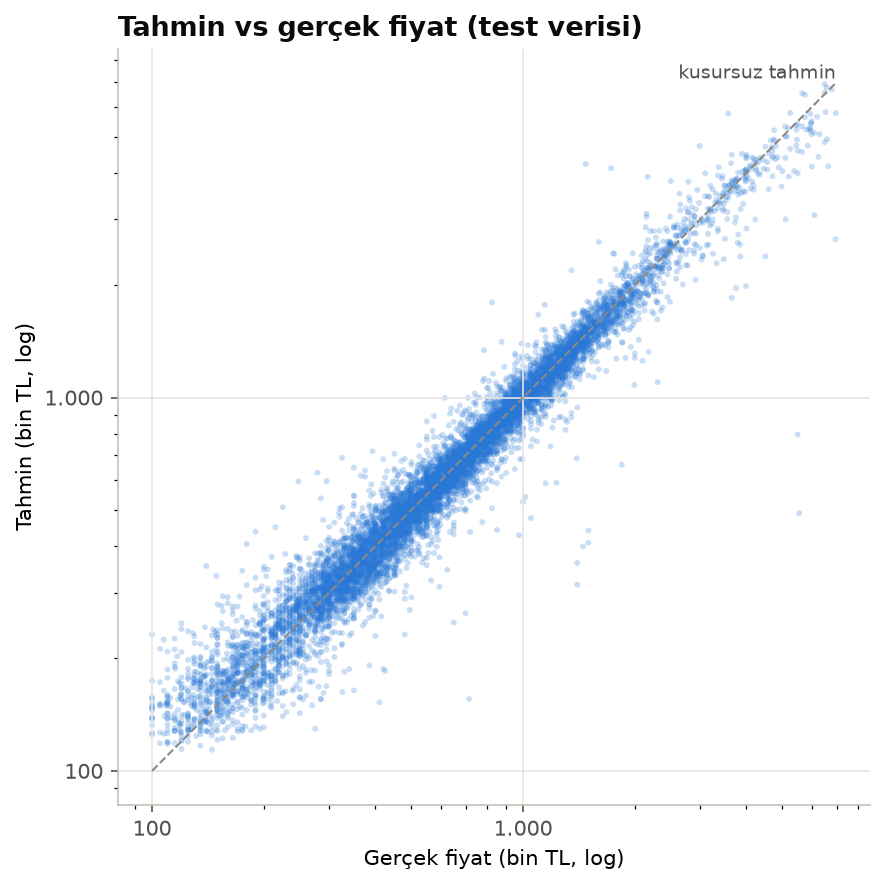

In [14]:
fig, ax = plt.subplots(figsize=(6, 6), dpi=150)
ax.scatter(y_test / 1e3, tahmin / 1e3, s=8, alpha=0.25, color=ANA, edgecolor="none")
sinir = [y_test.min() / 1e3, y_test.max() / 1e3]
ax.plot(sinir, sinir, color=SOLUK, linestyle="--", linewidth=1)
ax.text(sinir[1], sinir[1], " kusursuz tahmin", color=IKINCIL, fontsize=9, va="bottom", ha="right")
ax.set_xscale("log"); ax.set_yscale("log")
fmt = FuncFormatter(lambda v, _: sayi(v)); ax.xaxis.set_major_formatter(fmt); ax.yaxis.set_major_formatter(fmt)
ax.set_title("Tahmin vs gerçek fiyat (test verisi)", loc="left", fontsize=13, fontweight="bold", color=METIN)
ax.set_xlabel("Gerçek fiyat (bin TL, log)"); ax.set_ylabel("Tahmin (bin TL, log)")
sade(ax); ax.grid(axis="x", color=IZGARA, linewidth=0.8)
fig.tight_layout(); fig.savefig(CIKTI / "tahmin_gercek.png", bbox_inches="tight"); plt.show()

### Model en çok neye bakıyor?

*Permutation importance:* bir sütunun değerlerini karıştırıp hatanın ne kadar arttığına bakıyoruz. Çok artıyorsa
model o sütuna çok güveniyor demektir.

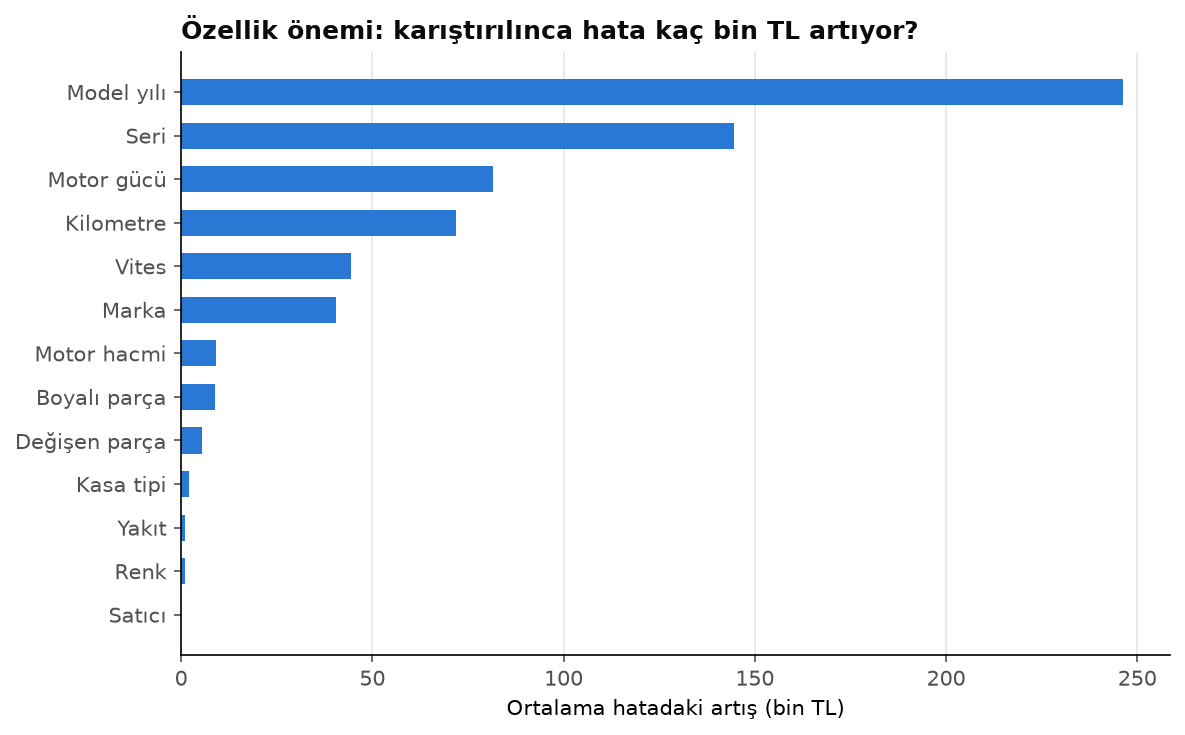

In [15]:
onem = permutation_importance(boosting, X_test, y_test, n_repeats=5, random_state=42,
                              scoring="neg_mean_absolute_error", n_jobs=-1)
onem = pd.Series(onem.importances_mean, index=X_test.columns).sort_values()
ADLAR = {"yil": "Model yılı", "kilometre": "Kilometre", "motor_hacmi": "Motor hacmi", "motor_gucu": "Motor gücü",
         "degisen_sayisi": "Değişen parça", "boyali_sayisi": "Boyalı parça", "marka": "Marka", "seri": "Seri",
         "vites_tipi": "Vites", "yakit_tipi": "Yakıt", "kasa_tipi": "Kasa tipi", "renk": "Renk", "kimden": "Satıcı"}

fig, ax = plt.subplots(figsize=(8, 5), dpi=150)
ax.barh([ADLAR[c] for c in onem.index], onem.values / 1e3, color=ANA, height=0.6)
ax.set_title("Özellik önemi: karıştırılınca hata kaç bin TL artıyor?", loc="left", fontsize=12, fontweight="bold", color=METIN)
ax.set_xlabel("Ortalama hatadaki artış (bin TL)")
ax.grid(axis="x", color=IZGARA, linewidth=0.8); ax.set_axisbelow(True)
for k in ("top", "right"): ax.spines[k].set_visible(False)
ax.tick_params(colors=IKINCIL)
fig.tight_layout(); fig.savefig(CIKTI / "ozellik_onemi.png", bbox_inches="tight"); plt.show()

## 8. Modeli ve arayüz seçeneklerini kaydetme

Model `model/fiyat_modeli.joblib` dosyasına kaydedildi. Arayüzün ihtiyaç duyduğu bilgileri de ayrı bir JSON'a yazıyoruz:
marka → seri listesi, her serinin tipik motor/yakıt/vites/kasa değerleri (formu önceden doldurmak için),
seçenek listeleri, geçerli aralıklar ve modelin hata oranı.

In [16]:
en_sik = lambda s: s.mode().iat[0] if not s.mode().empty else None
seri_ozet = (X_egitim.groupby(["marka", "seri"])
             .agg(adet=("yil", "size"), motor_hacmi=("motor_hacmi", "median"), motor_gucu=("motor_gucu", "median"),
                  yakit_tipi=("yakit_tipi", en_sik), vites_tipi=("vites_tipi", en_sik), kasa_tipi=("kasa_tipi", en_sik),
                  yil=("yil", "median"))
             .query("adet >= 10").reset_index())

secenekler = {
    "veri_tarihi": "Ağustos 2025",
    "markalar": {m: sorted(g["seri"].tolist()) for m, g in seri_ozet.groupby("marka")},
    "seri_varsayilan": {f"{r.marka}|{r.seri}": {"motor_hacmi": float(r.motor_hacmi), "motor_gucu": float(r.motor_gucu),
                                                 "yakit_tipi": r.yakit_tipi, "vites_tipi": r.vites_tipi,
                                                 "kasa_tipi": r.kasa_tipi, "yil": int(r.yil), "adet": int(r.adet)}
                        for r in seri_ozet.itertuples()},
    **{c: X_egitim[c].value_counts().index.tolist() for c in ["vites_tipi", "yakit_tipi", "kasa_tipi", "renk", "kimden"]},
    "aralik": {"yil": [int(df["yil"].min()), int(df["yil"].max())], "kilometre": [0, 1_000_000],
               "fiyat": [float(alt), float(ust)]},
    "basari": {"mae_tl": float(en_iyi["MAE (TL)"]), "medyan_yuzde_hata": float(en_iyi["medyan % hata"]),
               "r2": float(en_iyi["R²"]), "egitim_satir": len(X_egitim), "test_satir": len(X_test)},
}
(MODEL / "secenekler.json").write_text(json.dumps(secenekler, ensure_ascii=False, indent=1), encoding="utf-8")
print(f"{len(secenekler['markalar'])} marka, {len(secenekler['seri_varsayilan'])} seri kaydedildi.")

45 marka, 243 seri kaydedildi.
